Import required libraries

In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

Function Definitions Required to Calculate NCF

In [2]:
def modi_deg(G,i,W_):
    d_i = G.degree(i, weight='weight')
    m_deg = (d_i/W_)/2
    return m_deg

def edge_weighted(G,i):
    all_edges = []
    nbr_i = list(G.neighbors(i))
    for n in range(0,len(nbr_i)):
        j = nbr_i[n]
        adjacent_edges_j = list(G.edges(j))
        all_edges.append(adjacent_edges_j)

    all_edges = list(all_edges)
    al_edges = []
    for e in range(0,len(all_edges)):
        al_edges = al_edges + all_edges[e]

    rmv_edges = []
    for e_ in range(0, len(al_edges)):
        ed = al_edges[e_]
        if((ed[0] == i) or (ed[1] == i)):
            rmv_edges.append(ed)

    for ed in range(0, len(rmv_edges)):
        rmv_e = rmv_edges[ed]
        al_edges.remove(rmv_e)

    if(len(al_edges) == 0):
        return 0
    else:
        refined_edges = list({*map(tuple, map(sorted, al_edges))})

        ew_i = 0
        for a in range(0,len(refined_edges)):
            ii = refined_edges[a][0]
            jj = refined_edges[a][1]
            w_jk = G.get_edge_data(ii, jj)
            val = w_jk['weight']
            ew_i = ew_i + val

        return ew_i

def weight_of_a_node(G,i,W_1):
    m_deg = modi_deg(G,i,W_1)
    deg_i = G.degree(i, weight='weight')
    edge_wt = edge_weighted(G,i)
    value = (deg_i + edge_wt)/W_1
    weight_value = value * m_deg
    return weight_value


def weighted_cness(G, W):
    nodes = list(G.nodes())
    w_closeness = []
    for i in range(0, len(nodes)):
        closeness = []
        nd = nodes[i]
        weight = weight_of_a_node(G,nd,W)
        #v = edge_weighted(G,nd)
        closeness.append(nd)
        closeness.append(weight)
        #closeness.append(v)
        w_closeness.append(closeness)
    return w_closeness


# Total Edge Weight of a Graph
def total_weight_of_G(G):
    edge_weights = list(G.edges.data('weight'))
    W_ = 0
    for e in range(len(edge_weights)):
        w = edge_weights[e][2]
        W_ += w
    return W_

Provide an input graph to calculate the NCF

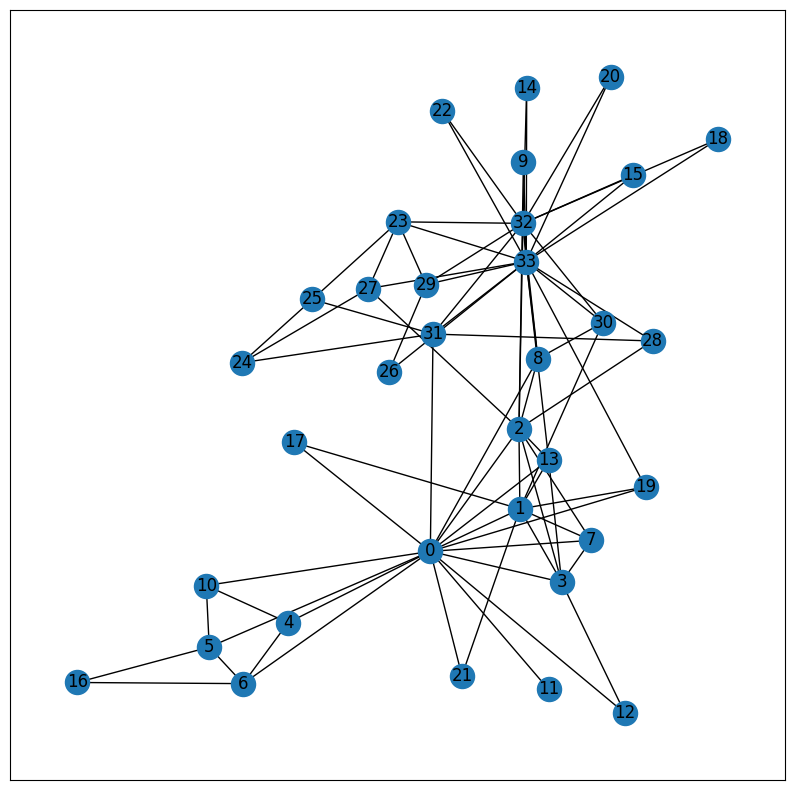

In [3]:
ss_1 = nx.read_weighted_edgelist('karate_club_w.txt', delimiter=',')
#print(nx.info(ss_1))

plt.figure(figsize = (10,10))
nx.draw_networkx(ss_1)
plt.show()

NCF result of the nodes present in the given graph

In [4]:
total_edge_weight = total_weight_of_G(ss_1)
w_ncf = weighted_cness(ss_1,total_edge_weight)
print(w_ncf)

[['0', 0.0590318772136954], ['1', 0.030162478214426264], ['2', 0.049783549783549784], ['3', 0.017034913138809244], ['4', 0.004347744607484867], ['5', 0.00800209891118982], ['6', 0.007430520417533405], ['7', 0.011937557392102848], ['8', 0.024531024531024532], ['9', 0.002276943835385394], ['10', 0.004347744607484867], ['11', 0.001180637544273908], ['12', 0.0021363917467813573], ['13', 0.023256685594347935], ['33', 0.06656546916287176], ['14', 0.0037949063923089898], ['32', 0.05269766308727348], ['15', 0.005312868949232586], ['16', 0.0012368583797155227], ['17', 0.0018833979872940913], ['18', 0.002276943835385394], ['19', 0.005387830063154738], ['21', 0.0025111973163921214], ['23', 0.021841794569067298], ['25', 0.006165551620097074], ['27', 0.012790240062967336], ['24', 0.002689229961957235], ['28', 0.005509641873278237], ['29', 0.01181574558197935], ['26', 0.0033170292910552654], ['30', 0.012368583797155224], ['31', 0.028728846910665094], ['20', 0.0030359251138471917], ['22', 0.003794906